In [39]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from typing import Tuple, List, Optional
from tqdm import tqdm 
from einops import rearrange, repeat, reduce, einsum

In [3]:

def euler_maruyama(f, g, x0, t_span, n_steps, forward=True, seed=None):
    """
    Euler-Maruyama integrator for SDEs of the form:
    dX_t = f(X_t, t)dt + g(X_t, t)dW_t
    
    Parameters:
    -----------
    f : callable
        Drift function f(x, t)
    g : callable  
        Diffusion function g(x, t)
    x0 : float
        Initial condition
    t_span : tuple
        Time span (t_start, t_end)
    dt : float
        Time step size
    forward : bool, optional
        If True, integrates forward in time; if False, backward in time. t_start < t_end always, if forward is False the integration is done from t_end to t_start.
    n_steps : int
        Number of time steps to take
    seed : int, optional
        Random seed for reproducibility
        
    Returns:
    --------
    t : ndarray
        Time points
    x : ndarray
        Solution values
    """
    if seed is not None:
        torch.random.seed(seed)
    t_start, t_end = t_span
    dt = torch.tensor((t_end - t_start) / n_steps, dtype=torch.float32)
    t = torch.linspace(t_start, t_end, n_steps, dtype=torch.float32)
    n_steps = len(t)
    
    # Generate Brownian motion increments
    dW = torch.randn((n_steps - 1,) + x0.shape, dtype=torch.float32) * torch.sqrt(dt)

    # Initialize trajectory list and add initial condition
    traj_list = [x0]

    # Euler-Maruyama iteration
    x_current = x0
    for i in range(n_steps - 1):
        t_curr = t[i] if forward else t[n_steps - 1 - i]
        x_next = x_current + f(x_current, t_curr) * dt + g(x_current, t_curr) * dW[i]
        traj_list.append(x_next)
        x_current = x_next
    
    # Stack into tensor
    traj = torch.stack(traj_list, dim=-1)

    return t, traj

reverse_time_em = lambda f, g, score, x0, t_span, n_steps, seed=None: euler_maruyama(
    lambda x, t: -f(x, t) + g(x, t)**2 * score(x, t),
    lambda x, t: g(x, t),
    x0,
    t_span,
    n_steps,
    forward=False,
    seed=seed, 
)

In [4]:
drift = lambda x, t: torch.zeros_like(x)
diffusion = lambda x, t: (2*t).sqrt()

t, traj = euler_maruyama(
    drift,
    diffusion,
    x0=torch.tensor([0.0, 0.0]),
    t_span=(0, 1),
    n_steps=100,
)

In [5]:
batch_em = torch.vmap(euler_maruyama, in_dims=(None, None, 0, None, None), out_dims=(None, 0), randomness="different")
batch_reverse_time_em = torch.vmap(reverse_time_em, in_dims=(None, None, None, 0, None, None), out_dims=(None, 0), randomness="different")
t, traj = batch_em(drift, diffusion, torch.zeros(1000,2), (0.01, 1), 200)
t_reverse, traj_reverse = batch_reverse_time_em(drift, diffusion, lambda x, t: -x / (t**2), traj[:,:,-1], (0.01, 1), 200)
bias = 1
t_reverse_approx, traj_reverse_approx = batch_reverse_time_em(drift, diffusion, lambda x, t: (-x + bias) / (t**2), traj[:,:,-1], (0.01, 1), 200)

In [5]:
print(traj_reverse[0,:,-5:])
print(traj_reverse_approx[0,:,-5:]) 

tensor([[-0.0304, -0.0002, -0.0187, -0.0016,  0.0212],
        [ 0.0209,  0.0045,  0.0006,  0.0171,  0.0154]])
tensor([[0.9882, 0.9837, 0.9944, 0.9767, 0.9943],
        [0.9961, 1.0048, 1.0083, 1.0154, 1.0235]])


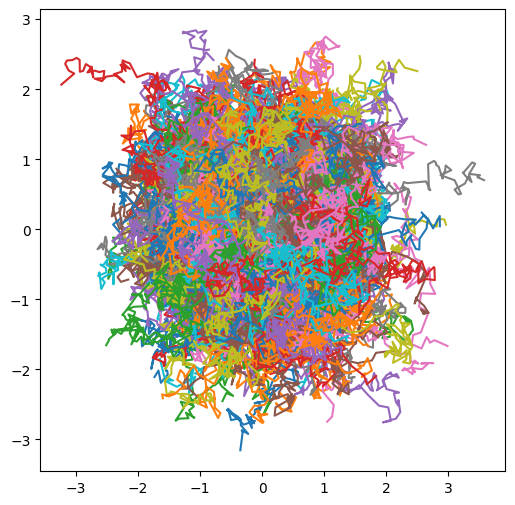

In [6]:
fig, ax = plt.subplots(figsize=(6,6))
# ax.scatter(traj[:,0], traj[:,1], label='Trajectory', c=t.numpy())
for i in range(traj.shape[0]):
    ax.plot(traj[i,0,:], traj[i,1,:], label='Trajectory')

MovieWriter Pillow unavailable; using Pillow instead.


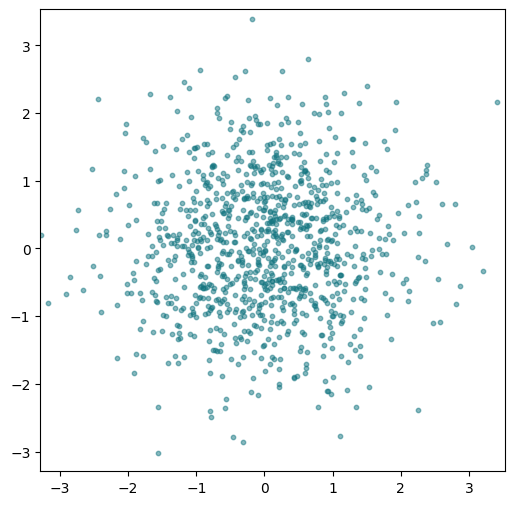

In [7]:
# make a gif that animates the trajectories
# traj is shape (batch, dim, time)
# plot a scatter for each time step

fig, ax = plt.subplots(figsize=(6,6))
scat = ax.scatter([], [], s=10, alpha=0.5, c="#137580")
ax.set_xlim(traj.min().item(), traj.max().item())
ax.set_ylim(traj.min().item(), traj.max().item())
def update(frame):
    scat.set_offsets(traj[:, :, frame].numpy(), )
    return scat,
ani = animation.FuncAnimation(fig, update, frames=traj.shape[2], blit=True)
ani.save('sde_trajectories.gif', writer='Pillow', fps=20)  

MovieWriter Pillow unavailable; using Pillow instead.


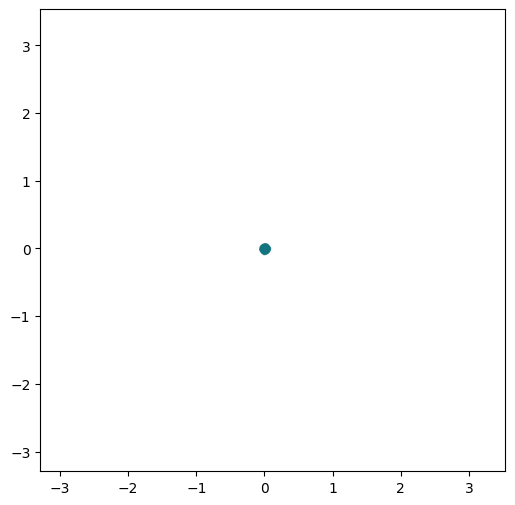

In [8]:
# make a gif that animates the trajectories first forward, then reverse time
# traj is shape (batch, dim, time)
# plot a scatter for each time step

concat_traj = torch.cat((traj, traj_reverse), dim=-1)  # Concatenate forward and reverse trajectories
fig, ax = plt.subplots(figsize=(6,6))
scat = ax.scatter([], [], s=10, alpha=0.5, c="#137580")
ax.set_xlim(concat_traj.min().item(), concat_traj.max().item())
ax.set_ylim(concat_traj.min().item(), concat_traj.max().item())
def update(frame):
    scat.set_offsets(concat_traj[:, :, frame].numpy(), )
    return scat,
ani = animation.FuncAnimation(fig, update, frames=concat_traj.shape[2], blit=True)
ani.save('fwd_rev_trajectories.gif', writer='Pillow', fps=20)  

MovieWriter Pillow unavailable; using Pillow instead.


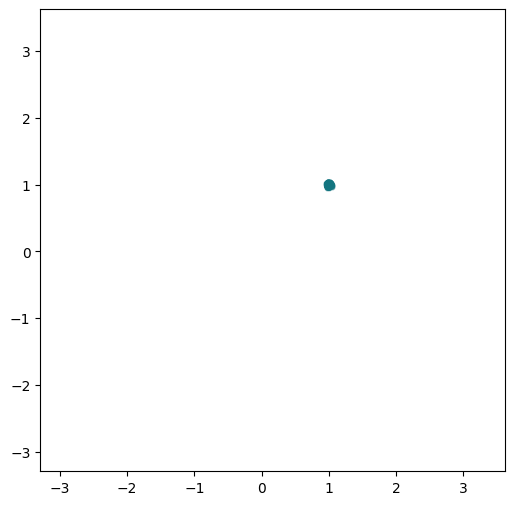

In [9]:
# make a gif that animates the trajectories first forward, then reverse time
# this time, we add a bias to the reverse time trajectory to simulate an approximate score model
# traj is shape (batch, dim, time)
# plot a scatter for each time step

concat_traj = torch.cat((traj, traj_reverse_approx), dim=-1)  # Concatenate forward and reverse trajectories
fig, ax = plt.subplots(figsize=(6,6))
scat = ax.scatter([], [], s=10, alpha=0.5, c="#137580")
ax.set_xlim(concat_traj.min().item(), concat_traj.max().item())
ax.set_ylim(concat_traj.min().item(), concat_traj.max().item())
def update(frame):
    scat.set_offsets(concat_traj[:, :, frame].numpy(), )
    return scat,
ani = animation.FuncAnimation(fig, update, frames=concat_traj.shape[2], blit=True)
ani.save('fwd_rev_approx_trajectories.gif', writer='Pillow', fps=20)  

In [10]:
center_a = torch.zeros(2)
center_b = torch.ones(2)
drift_a = lambda x, t: (center_a - x)
drift_b = lambda x, t: (center_b - x)
diffusion = lambda x, t: (2*t).sqrt()

initial_conditions = torch.rand(1000, 2)
t_a, traj_a = batch_em(drift_a, diffusion, initial_conditions, (0.01,1), 200)
t_b, traj_b = batch_em(drift_b, diffusion, initial_conditions, (0.01,1), 200)

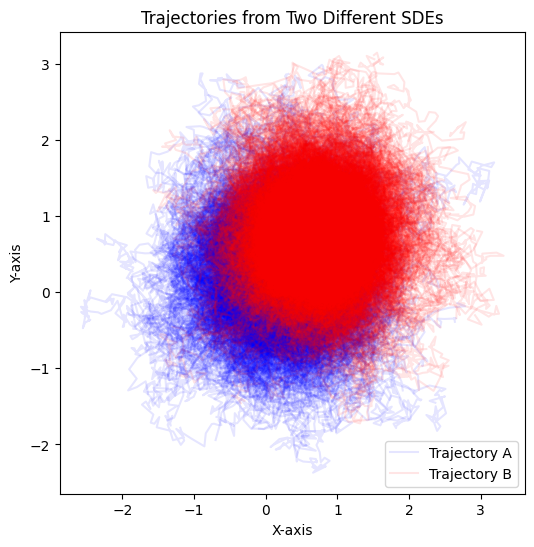

In [11]:
fig, ax = plt.subplots(figsize=(6,6))
for i in range(traj_a.shape[0]):
    ax.plot(traj_a[i,0,:], traj_a[i,1,:], label='Trajectory A' if i==0 else None, c='blue', alpha=0.1)
for i in range(traj_b.shape[0]):
    ax.plot(traj_b[i,0,:], traj_b[i,1,:], label='Trajectory B' if i==0 else None, c='red', alpha=0.1)

ax.set_title('Trajectories from Two Different SDEs')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.legend()
plt.show()

MovieWriter Pillow unavailable; using Pillow instead.


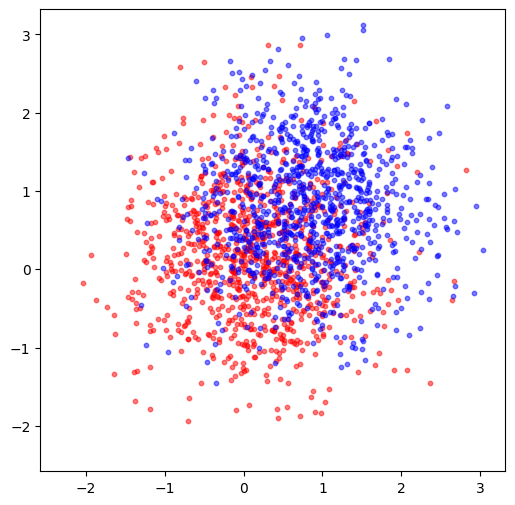

In [12]:
fig, ax = plt.subplots(figsize=(6,6))
scat_a = ax.scatter([], [], s=10, alpha=0.5, c="red")
scat_b = ax.scatter([], [], s=10, alpha=0.5, c="blue")

mins = min(traj_a.min().item(), traj_b.min().item())
maxs = max(traj_a.max().item(), traj_b.max().item())
ax.set_xlim(mins, maxs)
ax.set_ylim(mins, maxs)

def update(frame):
    scat_a.set_offsets(traj_a[:, :, frame].numpy())
    scat_b.set_offsets(traj_b[:, :, frame].numpy())
    return scat_a, scat_b

ani = animation.FuncAnimation(fig, update, frames=traj_a.shape[2], blit=True)
ani.save('sde_trajectories_a_b.gif', writer='Pillow', fps=20)

In [6]:

class ForwardReversePathEstimator:
    """
    Monte Carlo estimator for log probability differences using the 
    path integral formula derived from proper application of Itô's formula.
    """

    def __init__(self, score_model, score_div, f, g, terminal_variance, dim=2, t_start=0.01, t_end=1.0, hutchinson_samples=10):
        """
        Args:
            score_model: Neural network that outputs score function s(x,t)
            f: Drift function f(x,t)
            g: Diffusion function g(x,t)
            terminal_variance: Terminal variance for the diffusion process
            t_start: Start time for the diffusion process
            t_end: End time for the diffusion process
            hutchinson_samples: Number of samples for Hutchinson trace estimator
        """
        self.score_model = score_model
        self.f = f
        self.g = g  # Drift and diffusion functions
        self.t_start = t_start
        self.t_end = t_end
        self.hutchinson_samples = hutchinson_samples
        self.terminal_variance = terminal_variance
        self.final_dist = torch.distributions.MultivariateNormal(torch.zeros(dim), torch.eye(dim) * self.terminal_variance)
        self.score_div = score_div  # Score divergence function
        self.f_div = lambda x, t: torch.zeros_like(x).sum(-1)  # Placeholder for drift divergence

    def estimate_log_prob_difference(self,
                                   state_A: torch.Tensor,
                                   state_B: torch.Tensor,
                                   n_samples: int = 1000,
                                   n_steps: int = 100,
                                   method: str = 'forward') -> Tuple[float, float]:
        """
        Estimate log p(A) - log p(B) using the path integral.
        
        The correct formula is:
        log p_0(X_0) = log p_T(X_T) - ∫[-∇·f + g²∇·s + ½g²|s|²]dt - ∫s·g dW
        """
        log_prob_diffs = []
        x_final_A = []
        x_final_B = []

        for _ in tqdm(range(n_samples)):
            if method == 'forward':
                log_prob_A, x_f_A = self._compute_forward_path_log_prob(state_A, n_steps)
                log_prob_B, x_f_B = self._compute_forward_path_log_prob(state_B, n_steps)
            else:  # reverse
                log_prob_A = self._compute_reverse_path_log_prob(state_A, n_steps)
                log_prob_B = self._compute_reverse_path_log_prob(state_B, n_steps)

            log_prob_diffs.append(log_prob_A - log_prob_B)
            x_final_B.append(x_f_B)
            x_final_A.append(x_f_A)
        estimate = np.mean(log_prob_diffs)
        std_error = np.std(log_prob_diffs) / np.sqrt(n_samples)
        
        return estimate, std_error, torch.stack(x_final_A), torch.stack(x_final_B)
    
    def _compute_forward_path_log_prob(self, 
                                               initial_state: torch.Tensor,
                                               n_steps: int) -> float:
        """
        Compute log probability using the FORWARD path integral:

        log p_0(x_0) = log p_T(x_T) - ∫₀ᵀ [-∇·f + g²∇·s + ½g²|s|²] dt - ∫₀ᵀ s·g dW
        """
        dt = torch.tensor( (self.t_end - self.t_start) / n_steps)

        x = initial_state.clone()
        
        # Initialize path integral components
        log_prob = torch.zeros(1, dtype=torch.float32)
        stochastic_integral = torch.zeros(1, dtype=torch.float32)
        drift_integral = torch.zeros(1, dtype=torch.float32)

        # Forward diffusion path
        for step in range(1,n_steps):
            t = step * dt
            g_t = self.g(x, t)

            # Get score at current state and time
            with torch.no_grad():
                score = self.score_model(x, torch.tensor(t))
            
            # Sample noise increment
            dW = torch.randn_like(x) * np.sqrt(dt)
            
                
            drift = self.f(x, t)
            dx = drift * dt + g_t * dW
            
            # === COMPUTE ALL FOUR TERMS OF THE CORRECTED INTEGRAL ===

            div_drift = self.f_div(x, t)

            # Term 2: g²∇·s (divergence of score, expensive!)
            div_score = self._compute_score_divergence_hutchinson(x, t)
            # div_score = -2 / t**2 # true value for this specific case


            # Term 3: ½g²|s|² (score magnitude squared)
            score_mag_sq = torch.norm(score, dim=-1)**2
            
            # Term 4: s·g dW (stochastic integral increment)
            stoch_increment = torch.sum(score * g_t * dW, dim=-1)
            
            # Accumulate integrals
            drift_contrib = (-div_drift + (g_t**2 * div_score) + (0.5 * g_t**2 * score_mag_sq)) * dt
            drift_integral += drift_contrib
            stochastic_integral += stoch_increment
            
            # Update state
            x = x + dx
            assert torch.isfinite(x).all(), "State became NaN during integration"
            assert torch.isfinite(drift_integral).all(), "Drift integral became NaN during integration"
        
        # Terminal log probability: log p_T(x_T)
        terminal_log_prob = self.final_dist.log_prob(x)

        # Apply corrected formula
        log_prob = terminal_log_prob - drift_integral - stochastic_integral
        
        return log_prob, x

    # def _compute_reverse_path_log_prob(self,
    #                                            target_state: torch.Tensor,
    #                                            n_steps: int) -> float:
    #     """
    #     Compute log probability using reverse-time generation with corrected integrals.
        
    #     For reverse SDE: dX = [f - g²s] dt + g dW
    #     We integrate the path probability in reverse time.
    #     """
    #     dt = (self.t_end - self.t_start) / n_steps

    #     # Start from noise
    #     x = torch.randn_like(target_state)
        
    #     # Initial noise log probability
    #     log_prob = -0.5 * torch.sum(x**2).item() - 0.5 * x.numel() * np.log(2 * np.pi)
        
    #     # Integrals for reverse process
    #     drift_integral = 0.0
    #     stochastic_integral = 0.0
        
    #     # Reverse SDE integration
    #     for step in range(n_steps):
    #         t = self.t_end - step * dt  # Reverse time
    #         beta_t = self.beta(t)
    #         g_t = np.sqrt(beta_t)
            
    #         with torch.no_grad():
    #             score = self.score_model(x, torch.tensor(t))
            
    #         # Reverse SDE: dX = [f(X,t) - g²(t)s(X,t)] dt + g(t) dW
    #         drift_original = -0.5 * beta_t * x  # Original forward drift
    #         drift_correction = -g_t**2 * score   # Score-based correction
    #         total_drift = drift_original + drift_correction
            
    #         # Sample noise
    #         dW = torch.randn_like(x) * np.sqrt(dt)
    #         dx = total_drift * dt + g_t * dW
            
    #         # === CORRECTED PATH INTEGRAL FOR REVERSE PROCESS ===
            
    #         # The reverse process has modified dynamics, so we need to account
    #         # for the path probability under the reverse SDE
            
    #         # Divergence of modified drift: ∇·[f - g²s]
    #         div_original_drift = -0.5 * beta_t * x.numel()
    #         div_score_term = self._compute_score_divergence_hutchinson(x, t)
    #         div_total_drift = div_original_drift - g_t**2 * div_score_term
            
    #         # Score magnitude for reverse process
    #         score_mag_sq = torch.sum(score * score).item()
            
    #         # Stochastic integral
    #         stoch_increment = torch.sum(score * g_t * dW).item()
            
    #         # Accumulate (note: signs may differ for reverse integration)
    #         drift_contrib = (-div_total_drift + 0.5 * g_t**2 * score_mag_sq) * dt
    #         drift_integral += drift_contrib
    #         stochastic_integral += stoch_increment
            
    #         # Update state
    #         x = x + dx
        
    #     # Penalty for distance from target (for conditional generation)
    #     # target_penalty = 0.5 * torch.sum((x - target_state)**2).item()
    #     target_penalty = 0
        
    #     # Apply corrected reverse formula
    #     log_prob = log_prob - drift_integral - stochastic_integral - target_penalty
        
    #     return log_prob
    
    def _compute_score_divergence_hutchinson(self, x: torch.Tensor, t: float) -> float:
        """
        Compute ∇·s(x,t) using Hutchinson's trace estimator.
        
        This is the expensive operation that makes exact path integrals costly.
        ∇·s ≈ E[ε^T ∇_x(s(x,t)·ε)] where ε ~ N(0,I)
        """
        if self.score_div is not None:
            return self.score_div(x, t)
        x_copy = x.clone().requires_grad_(True)
        
        divergence_estimate = 0.0
        
        for _ in range(self.hutchinson_samples):
            # Sample random vector
            epsilon = torch.randn_like(x)
            
            # Compute score
            score = self.score_model(x_copy, torch.tensor(t))
            
            # Compute s·ε
            score_dot_eps = torch.sum(score * epsilon)
            
            # Compute gradient ∇_x(s·ε)
            grad = torch.autograd.grad(score_dot_eps, x_copy, retain_graph=True)[0]
            
            # Compute ε^T ∇_x(s·ε)
            divergence_estimate += torch.sum(epsilon * grad).item()
            assert torch.isfinite(grad).all(), "grad estimate became NaN during computation"
        
        return divergence_estimate / self.hutchinson_samples
    


In [7]:
point_A = torch.tensor([0.1, 0.1])
point_B = torch.tensor([1.0, 1.0])

# f(x,t) = 0 and g(x,t) = sqrt(2*t) for Karras
# true p(x,t) = N(x; mu_t, 1 + sigma_t^2 I)
score_model = lambda x, t: -x /(1 + t**2)
score_div = lambda x, t: -2 / (1 + t**2)  # True divergence for this specific case (set to None if you want to use Hutchinson)
f = lambda x, t: torch.zeros_like(x)
g = lambda x, t: (2*t).sqrt()


t_start = 0.001
t_end = 10.0

est = ForwardReversePathEstimator(score_model, score_div, f, g, terminal_variance=t_end**2, t_start=t_start, t_end=t_end, hutchinson_samples=100)
# Estimate log p(point_A) - log p(point_B)
estimate, std_error, x_final_A, x_final_B = est.estimate_log_prob_difference(point_A, point_B, n_samples=500, n_steps=100, method='forward')

  0%|          | 0/500 [00:00<?, ?it/s]

/tmp/ipykernel_1563084/2063906790.py:85: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  score = self.score_model(x, torch.tensor(t))
100%|██████████| 500/500 [00:11<00:00, 45.13it/s]


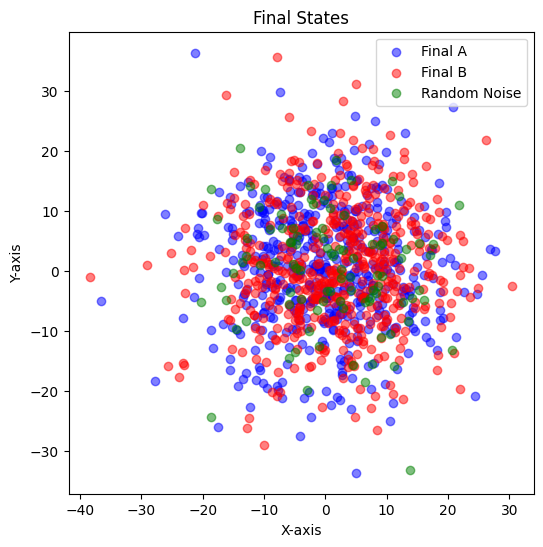

In [8]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(x_final_A[:, 0].numpy(), x_final_A[:, 1].numpy(), label='Final A', c='blue', alpha=0.5)
ax.scatter(x_final_B[:, 0].numpy(), x_final_B[:, 1].numpy(), label='Final B', c='red', alpha=0.5)
ax.scatter(*torch.randn(2,100)*10, label='Random Noise', c='green', alpha=0.5)
ax.set_title(f'Final States')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.legend()
plt.show()

In [9]:
true_dist = torch.distributions.MultivariateNormal(torch.zeros(2), torch.eye(2))
true_log_prob_A = true_dist.log_prob(point_A)
true_log_prob_B = true_dist.log_prob(point_B)

print(f"Estimated log p(A) - log p(B): {estimate:.4f} ± {std_error:.4f}")
print(f"True log p(A): {true_log_prob_A:.4f}, True log p(B): {true_log_prob_B:.4f}")
print(f"True difference: {true_log_prob_A - true_log_prob_B:.4f}")

Estimated log p(A) - log p(B): 1.0244 ± 0.0332
True log p(A): -1.8479, True log p(B): -2.8379
True difference: 0.9900


In [ ]:
# calculate the path measure for a given trajectory in reverse time using the Onsager-Machlup formula
# this will allow us to weight how likely forward trajectories are in reverse time using our approximate
# reverse path learned by the score model

# def log_path_measure_reverse_time(forward_trajectory, timesteps, score_model, f, g, dim):
#     """
#         Args:
#         forward_trajectory: Tensor of shape (batch, dim, timesteps) representing the forward trajectory.
#         timesteps: Tensor of shape (timesteps) Time points corresponding to the trajectory.
#         score_model: Neural network that outputs score function s(x,t).
#         f: Drift function f(x,t).
#         g: Diffusion function g(x,t).
#         t_start: Start time for the diffusion process.
#         t_end: End time for the diffusion process.
#         n_steps: Number of steps in the trajectory.
#     Calculate the path measure for a given forward trajectory in reverse time using the Onsager-Machlup formula.
    
#     For reverse time SDE: dX = [f(X,t) - g²(X,t)s(X,t)]dt + g(X,t)dW
#     We evaluate how likely the forward trajectory is under this reverse dynamics.
#     """
#     # Initialize path measure
#     log_p = torch.zeros(forward_trajectory.shape[0], dtype=torch.float32)

#     # Iterate BACKWARDS through time (reverse time dynamics)
#     for i in range(len(timesteps) - 1):
#         # Current time point (going backwards)
#         t_current = timesteps[-(i+1)]  # Start from end, go to beginning
#         dt = timesteps[1] - timesteps[0]  # Positive time step
        
#         # In reverse time: "current" is later in forward trajectory, "next" is earlier
#         curr_x = forward_trajectory[:, :, -(i+1)]  # Current state (later in forward time)
#         next_x = forward_trajectory[:, :, -(i+2)] if i < len(timesteps) - 2 else forward_trajectory[:, :, 0]  # Next state (earlier in forward time)
        
#         # Get the score function at current state and time
#         score = score_model(curr_x, t_current)

#         # Compute the drift and diffusion at current state and time
#         drift = f(curr_x, t_current)
#         diffusion = g(curr_x, t_current)

#         # Reverse time drift: f - g²s
#         reverse_time_drift = drift - (diffusion**2 * score)
        
#         # Expected displacement under reverse dynamics
#         expected_displacement = reverse_time_drift * dt
        
#         # Actual displacement in the trajectory (going backwards in time)
#         actual_displacement = next_x - curr_x  # This should match -expected_displacement
        
#         # Onsager-Machlup formula for reverse time
#         log_p += -dim/2 * torch.log(2 * np.pi * dt * diffusion**2)  # Gaussian normalization
#         log_p -= (1 / (2 * dt * diffusion**2)) * torch.norm(actual_displacement + expected_displacement, dim=-1)**2

#     return log_p

def log_path_measure_forward_time(forward_trajectory, timesteps, f, g, dim):
    """
    Calculate the path measure for a given forward trajectory in forward time using the Onsager-Machlup formula.
    
    Args:
        forward_trajectory: Tensor of shape (batch, dim, timesteps) representing the forward trajectory.
        timesteps: Tensor of shape (timesteps) Time points corresponding to the trajectory.
        score_model: Neural network that outputs score function s(x,t).
        f: Drift function f(x,t).
        g: Diffusion function g(x,t).
        t_start: Start time for the diffusion process.
        t_end: End time for the diffusion process.
        n_steps: Number of steps in the trajectory.
    """
    # Reverse time parameters

    # Initialize path measure
    log_p = torch.zeros(forward_trajectory.shape[0], dtype=torch.float32)

    # Iterate over time points
    for i in range(len(timesteps) - 1, 0, -1):
        t = timesteps[i]
        dt = timesteps[i] - timesteps[i-1]

        curr_x = forward_trajectory[:, :, i]
        prev_x = forward_trajectory[:, :, i-1]
        # Get the score function

        # Compute the drift and diffusion
        drift = f(curr_x, t)
        diffusion = g(curr_x, t)

        # Update the path measure using the Onsager-Machlup formula
        # log_p += -dim/2 * torch.log(2 * np.pi * dt * diffusion**2) # gaussian normalization term (can exclude for computing log ratios)
        log_p -= (1 / (2 * dt * diffusion**2)) * torch.norm(curr_x - prev_x - (drift * dt), dim=-1)**2  # quadratic term

    return log_p


def log_path_measure_reverse_time(forward_trajectory, timesteps, score_model, f, g, dim):
    """Calculate path measure under reverse-time dynamics"""
    log_p = torch.zeros(forward_trajectory.shape[0], dtype=torch.float32)
    
    # Iterate backwards through the forward trajectory
    for i in range(len(timesteps) - 1):
        t = timesteps[-(i+1)]  # Current time (going backwards)
        dt = timesteps[1] - timesteps[0]  # Keep positive dt
        
        # States: current (later in forward time) and next (earlier in forward time)
        curr_x = forward_trajectory[:, :, -(i+1)]
        next_x = forward_trajectory[:, :, -(i+2)] if i < len(timesteps) - 2 else forward_trajectory[:, :, 0]
        
        # Reverse-time drift: f - g²s
        score = score_model(curr_x, t)
        drift = f(curr_x, t)
        diffusion = g(curr_x, t)
        reverse_drift = drift - (diffusion**2 * score)
        
        # Expected displacement under reverse dynamics (going backwards in time)
        expected_displacement = -reverse_drift * dt  # Negative because we're going backwards
        
        # Actual displacement (from later to earlier state)
        actual_displacement = next_x - curr_x
        
        # Onsager-Machlup formula
        # log_p -= dim/2 * torch.log(2 * np.pi * dt * diffusion**2) # gaussian normalization term (can exclude for computing log ratios)
        log_p -= (1 / (2 * dt * diffusion**2)) * torch.norm(actual_displacement - expected_displacement, dim=-1)**2
        
    return log_p

In [110]:
# f(x,t) = 0 and g(x,t) = sqrt(2*t) for Karras
# true p(x,t) = N(x; mu_t, 1 + sigma_t^2 I)
exact_score = lambda x, t: -x /(1 + t**2) 
f = lambda x, t: torch.zeros_like(x)
g = lambda x, t: (2*t).sqrt()

timesteps, forward_trajectory = batch_em(f, g, torch.zeros(10,2), (0.01,1), 200)
reverse_trajectory = torch.flip(forward_trajectory, dims=[-1]).clone()  # Reverse the trajectory in time

print(log_path_measure_reverse_time(forward_trajectory, timesteps, exact_score, f, g, 2))
print(log_path_measure_reverse_time(reverse_trajectory, timesteps, exact_score, f, g, 2))

print(log_path_measure_forward_time(forward_trajectory, timesteps, f, g, 2))
print(log_path_measure_forward_time(reverse_trajectory, timesteps, f, g, 2))

tensor([-177.5901, -190.2830, -192.8445, -191.8450, -197.3974, -186.7581,
        -178.4457, -200.9437, -176.9644, -199.5766])
tensor([-580.7488, -590.6041, -844.1520, -526.1065, -693.1656, -557.2899,
        -545.6622, -833.2078, -615.8859, -817.6776])
tensor([-179.1478, -191.4897, -193.6799, -193.3332, -198.3761, -187.8686,
        -180.4185, -201.6873, -177.7934, -200.3336])
tensor([-579.6448, -590.3420, -844.7597, -525.2562, -693.5574, -557.1097,
        -543.7286, -834.0963, -616.2739, -818.5978])


In [ ]:
# f(x,t) = 0 and g(x,t) = sqrt(2*t) for Karras
# true p(x,t) = N(x; mu_t, 1 + sigma_t^2 I)
bias = 1.0
t_start = 0.001
variance_start = 1.0
t_end = 10.0
num_samples = 10000
num_timepoints = 200

true_score = lambda x, t: (-x) /(variance_start + t**2)  # add a small bias to the score to represent an approximate score model
approximate_score = lambda x, t: (-x + bias) /(variance_start + t**2)  # add a small bias to the score to represent an approximate score model
f = lambda x, t: torch.zeros_like(x)
g = lambda x, t: (2*t).sqrt()

timesteps, forward_trajectory = batch_em(f, g, variance_start * torch.randn(num_samples, 2), (t_start, t_end), num_timepoints)
timesteps_reverse, reverse_trajectory = batch_reverse_time_em(f, g, true_score, forward_trajectory[:,:,-1], (t_start, t_end), num_timepoints)
t_reverse, model_reverse_time_trajectory = batch_reverse_time_em(f, g, approximate_score, forward_trajectory[:,:,-1], (t_start, t_end), num_timepoints)


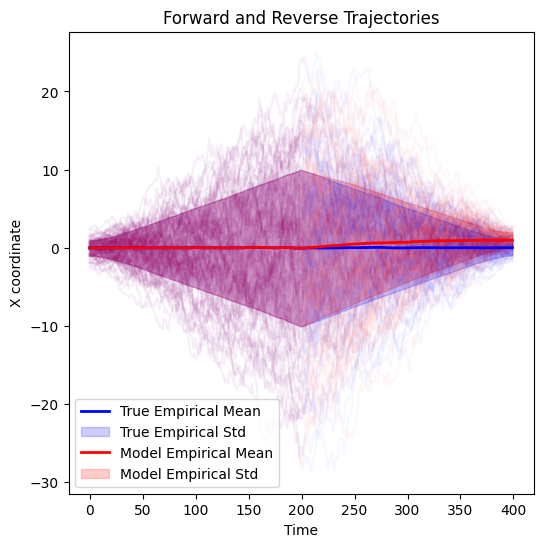

Start Mean True: -0.02, Start Std True: 1.00
Start Mean Model: -0.02, Start Std Model: 1.00
Midpoint Mean True: -0.04, Midpoint Std True: 10.00
Midpoint Mean Model: -0.04, Midpoint Std Model: 10.00
Final Mean True: 0.01, Final Std True: 1.00
Final Mean Model: 0.98, Final Std Model: 0.99


In [108]:
max_num_traces = 100
concat_correct_reversal = torch.cat((forward_trajectory, reverse_trajectory), dim=-1)  # Concatenate forward and reverse trajectories
empirical_mean_true = torch.mean(concat_correct_reversal, dim=0)
empirical_std_true = torch.std(concat_correct_reversal, dim=0)
concat_model_reversal = torch.cat((forward_trajectory, model_reverse_time_trajectory), dim=-1) 
empirical_mean_model = torch.mean(concat_model_reversal, dim=0)
empirical_std_model = torch.std(concat_model_reversal, dim=0)

fig, ax = plt.subplots(figsize=(6,6))

ax.plot(concat_correct_reversal[:max_num_traces,0,:].T, c='blue', alpha=3/max_num_traces)
ax.plot(concat_model_reversal[:max_num_traces,0,:].T, c='red', alpha=3/max_num_traces)
ax.plot(empirical_mean_true[0,:], label='True Empirical Mean', c='blue', linewidth=2)
ax.fill_between(torch.arange(empirical_mean_true.shape[1]), 
                empirical_mean_true[0,:] - empirical_std_true[0,:], 
                empirical_mean_true[0,:] + empirical_std_true[0,:], 
                color='blue', alpha=0.2, label='True Empirical Std')
ax.plot(empirical_mean_model[0,:], label='Model Empirical Mean', c='red', linewidth=2)
ax.fill_between(torch.arange(empirical_mean_model.shape[1]), 
                empirical_mean_model[0,:] - empirical_std_model[0,:], 
                empirical_mean_model[0,:] + empirical_std_model[0,:], 
                color='red', alpha=0.2, label='Model Empirical Std')
ax.set(title='Forward and Reverse Trajectories', xlabel='Time', ylabel='X coordinate')
ax.legend()
plt.show()



print(f"Start Mean True: {empirical_mean_true[0,0].item():.2f}, Start Std True: {empirical_std_true[0,0].item():.2f}")
print(f"Start Mean Model: {empirical_mean_model[0,0].item():.2f}, Start Std Model: {empirical_std_model[0,0].item():.2f}")
midpoint_index = empirical_mean_true.shape[1] // 2
print(f"Midpoint Mean True: {empirical_mean_true[0,midpoint_index].item():.2f}, Midpoint Std True: {empirical_std_true[0,midpoint_index].item():.2f}")
print(f"Midpoint Mean Model: {empirical_mean_model[0,midpoint_index].item():.2f}, Midpoint Std Model: {empirical_std_model[0,midpoint_index].item():.2f}")
print(f"Final Mean True: {empirical_mean_true[0,-1].item():.2f}, Final Std True: {empirical_std_true[0,-1].item():.2f}")
print(f"Final Mean Model: {empirical_mean_model[0,-1].item():.2f}, Final Std Model: {empirical_std_model[0,-1].item():.2f}")




In [109]:
# We want to evaluate the likelihood of producing a sample x under the approximate score model's reverse time trajectory
# but only simulate in forward time. The strategy is to use the path measure of the forward and reverse trajectories
# to weight the likelihood of the forward trajectory under the reverse time model.
# We also want to leverage that at t_end, we know the distribution is a Gaussian with mean 0 and variance t_end^2.

def evaluate_likelihood_under_reverse_model(datapoint, f, g, score_model, dim, t_start, t_end, terminal_dist, num_simulations=1000, num_timepoints=200):
    """
    Evaluate the likelihood of producing a sample x under the approximate score model's reverse time trajectory.
    
    Args:
        datapoint: single sample tensor of shape (dim,).
        f: Drift function f(x,t).
        g: Diffusion function g(x,t).
        score_model: Neural network that outputs score function s(x,t).
        dim: Dimensionality of the state space.
        t_start: Start time for the diffusion process.
        t_end: End time for the diffusion process.
        terminal_dist: Terminal distribution at t_end, typically a Gaussian. Must have a log_prob() method.
        num_simulations: Number of simulations to run.
        num_timepoints: Number of time points to simulate the trajectory.
    """
    timesteps, forward_trajectory = batch_em(f, g, datapoint.repeat(num_simulations, 1), (t_start, t_end), num_timepoints)

    # Calculate path measure for forward trajectory
    log_p_forward = log_path_measure_forward_time(forward_trajectory, timesteps, f, g, dim)
    
    # Calculate path measure for reverse trajectory using the approximate score model
    log_p_reverse = log_path_measure_reverse_time(forward_trajectory, timesteps, score_model, f, g, dim)
    
    # Terminal distribution at t_end is Gaussian with mean 0 and variance t_end^2
    t_end = timesteps[-1]
    
    # Evaluate likelihood at the last time point
    terminal_log_prob = terminal_dist.log_prob(forward_trajectory[:, :, -1])
    
    # Combine the log probabilities
    log_likelihood = terminal_log_prob + log_p_reverse - log_p_forward
    # log_likelihood = + log_p_reverse - log_p_forward
    # return log_likelihood.mean().item(), log_likelihood.std().item()

    log_mean = reduce(log_likelihood, "b -> 1", torch.logsumexp) - torch.log(torch.tensor(num_simulations, dtype=log_likelihood.dtype, device=log_likelihood.device))
    std_error = log_likelihood.exp().std() / torch.sqrt(torch.tensor(num_simulations, dtype=log_likelihood.dtype, device=log_likelihood.device))
    
    return log_mean.item(), std_error.item()

true_generation_dist = torch.distributions.MultivariateNormal(empirical_mean_model[:,-1], torch.diag(empirical_std_model[:,-1]**2))
prior_dist = torch.distributions.MultivariateNormal(torch.zeros(2), torch.eye(2) * t_end**2)
test_point_A = torch.tensor([0.1, 0.1])
test_point_B = torch.tensor([1.0, 1.0])
estimated_logp_A, std_error_A = evaluate_likelihood_under_reverse_model(
    datapoint=test_point_A, f=f, g=g, score_model=approximate_score,
    dim=2, t_start=t_start, t_end=t_end, terminal_dist=prior_dist, num_simulations=1000
)
estimated_logp_B, std_error_B = evaluate_likelihood_under_reverse_model(
    datapoint=test_point_B, f=f, g=g, score_model=approximate_score,
    dim=2, t_start=t_start, t_end=t_end, terminal_dist=prior_dist, num_simulations=1000
)
estimated_logp_diff = estimated_logp_A - estimated_logp_B
true_logp_diff = true_generation_dist.log_prob(test_point_A) - true_generation_dist.log_prob(test_point_B)

print(f"Estimated log p difference under reverse model: {estimated_logp_diff:.4f}")
print(f"std error: A={std_error_A:.4f}, B={std_error_B:.4f}")
print(f"True log p difference: {true_logp_diff:.4f}")


Estimated log p difference under reverse model: -0.7868
std error: A=0.0008, B=0.0017
True log p difference: -0.7732


In [34]:
empirical_std_true[:,-1]

tensor([0.9719, 0.9896])

In [66]:
empirical_mean_model.shape

torch.Size([2, 400])